## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Figure 3: Projecting HP demand impacts on power systems with leveraging its flexibility.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

### Figure 3(a): visualizes the Swiss electricity generation portfolio in the year of 2020, 2030, 2040 and 2050

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12068\3013466317.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


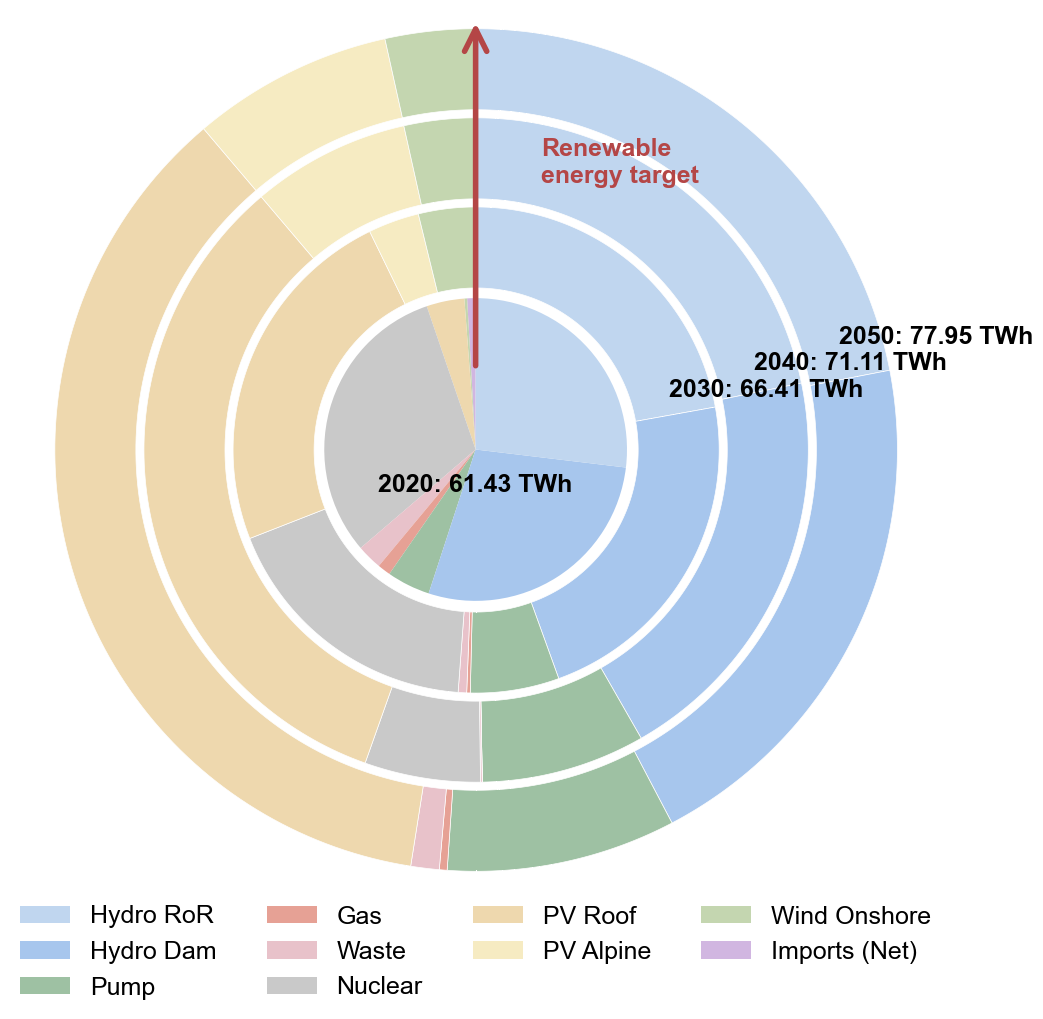

In [11]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 3(a)
# =====================================================================


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, FancyArrowPatch
import matplotlib as mpl
from pathlib import Path

# Convert polar coordinates to Cartesian coordinates
def polar_to_cartesian(theta, r):
    return r * np.cos(theta), r * np.sin(theta)

# ========= Custom technology ordering configuration =========
use_custom_order = True  # Enable custom ordering: True/False
custom_order = [
    'Hydro RoR','Hydro Dam','Pump','Gas','Waste','Nuclear',
    'PV Roof','PV Alpine','Wind Onshore','Imports (Net)'
]
custom_mode = 'prepend'  # 'prepend' | 'strict' | 'append'
# =======================================================================================================================

# ========= Manually specified demand values for four years (used only for text labels) =========
use_manual_demand = True  # If enabled, labels such as 'XXXX: YY.Y TWh' will use the values below
manual_demand = {
    '2020': 61.43,
    '2030': 66.41,
    '2040': 71.11,
    '2050': 77.95,
}
# =============================================================================================================================================

# File path
case = 'case1b'
country = 'ch'
file_path = fr"..\Output_data\power systems results\{case}\national_generation_and_capacity\0-national_generation_annual_twh_c_{country}.csv"

# Non-generation rows and gas categories to be aggregated
non_energy_rows = [
    'Battery (Load)', 'CAES (Load)', 'DAC (Load)', 'DSM', 'DSM (Up)', 'EMob Shift (Up)',
    'HP Shift', 'HP Shift (Up)', 'LAES (Load)', 'Load Shed', 'Load Shed Ind',
    'Methanation (Load)', 'P2G2P (Load)', 'Pump (Load)', 'Imports', 'Exports', 'Oil',
    'Load (Net)', 'Load (Total)'
]
gas_labels = ['Gas CC', 'Gas CC-CCS', 'Gas CC-Syn', 'Gas Other']

# Year order (inner to outer): center pie = 2020; outer rings = 2030, 2040, 2050
ordered_years = ['2020', '2030', '2040', '2050']

# ---------- Build technology ordering ----------
def build_labels_sorted(df, ordered_years, reference_year='2040',
                        # Build the plotting order based on a reference year,
                        # with optional manual overrides.

                        use_custom=False, custom_order=None, mode='prepend'):
    labels_all = df[df[ordered_years].gt(0).any(axis=1)].index.tolist()
    base_sorted = df.loc[labels_all, reference_year].fillna(0).sort_values(ascending=False).index.tolist()
    if not use_custom or not custom_order:
        return base_sorted
    custom_in_data = [lbl for lbl in custom_order if lbl in labels_all]
    invalid = [lbl for lbl in (custom_order or []) if lbl not in labels_all]
    if invalid:
        print(f"[Note] The following custom technologies were not found in the dataset and will be ignored: {invalid}")
    if mode == 'strict':
        return custom_in_data
    if mode == 'prepend':
        remainder = [lbl for lbl in base_sorted if lbl not in custom_in_data]
        return custom_in_data + remainder
    if mode == 'append':
        remainder = [lbl for lbl in custom_in_data if lbl not in base_sorted]
        return base_sorted + remainder
    remainder = [lbl for lbl in base_sorted if lbl not in custom_in_data]
    return custom_in_data + remainder
# ------------------------------------------------

# Load the annual generation data
# Read the CSV file and use the first column as the row index.
df = pd.read_csv(file_path)
df.rename(columns={df.columns[0]: 'Row'}, inplace=True)
df.set_index('Row', inplace=True)
df = df[~df.index.isin(non_energy_rows)]

# Aggregate all gas-related technologies into a single 'Gas' category
df.loc['Gas'] = df.reindex(gas_labels).fillna(0).sum()
df.drop(gas_labels, inplace=True, errors='ignore')

# Total generation used for plotting (positive values only)
# Compute yearly totals using only positive generation values.
year_totals_gen = df.where(df > 0).sum(axis=0)

# Totals shown in text labels: defaults to generation totals, but can be overwritten by manual demand values
label_totals = year_totals_gen.copy()
if use_manual_demand:
    for y in ordered_years:
        if y in manual_demand and manual_demand[y] is not None:
            label_totals[y] = float(manual_demand[y])

# Technology ordering for plotting and legend display
reference_year = '2040'
labels_sorted = build_labels_sorted(
    df, ordered_years,
    reference_year=reference_year,
    use_custom=use_custom_order,
    custom_order=custom_order,
    mode=custom_mode
)

# Color palette (Morandi-inspired tones)
color_map_final = {
    'Hydro Dam': '#A7C6ED',
    'Hydro RoR': '#C0D6EF',
    'Nuclear': '#C9C9C9',
    'PV Roof': '#EED8AE',
    'PV Alpine': '#F6EBC2',
    'Wind Onshore': '#C4D6B0',
    'Gas': '#E6A195',
    'Oil': '#D99879',
    'Waste': '#E8C2CA',
    'Pump': '#9EC1A3',
    'Imports (Net)': '#D1B6E1'
}

# Create the figure canvas
fig = plt.figure(figsize=(11, 11))

# Central pie chart for the year 2020
ax_pie = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax_pie.axis('equal')
year = ordered_years[0]  # '2020'
labels_for_pie = labels_sorted[::-1]
raw_values = df.loc[labels_for_pie, year].copy()
raw_values[raw_values < 0] = 0
raw_values = raw_values.fillna(0)
colors = [color_map_final.get(label, '#cccccc') for label in labels_for_pie]
wedges, _ = ax_pie.pie(raw_values, startangle=90, colors=colors, radius=0.43)

# Central text label using manual demand values or label_totals
ax_pie.text(0, -0.1, f"{year}: {label_totals.get(year, 0):.2f} TWh",
            ha='center', va='center',
            fontsize=18, fontweight='bold', color='black')

# Outer polar rings for future years
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], polar=True, zorder=2)
ax.set_facecolor('none')
width = 0.2
ring_spacing = 0.02
angle_limit = 2 * np.pi
inner_radius = 0.4

for i, y in enumerate(ordered_years[1:]):  # '2030', '2040', '2050'
    radius = inner_radius + i * (width + ring_spacing)
    # Angular allocation is still based on total generation
    year_total_for_angles = year_totals_gen.get(y, 0)
    if year_total_for_angles <= 0:
        continue
    current_angle = 0
    for label in labels_sorted:
        value = float(df.loc[label, y]) if pd.notna(df.loc[label, y]) else 0.0
        if value <= 0:
            continue
        angle = (value / year_total_for_angles) * angle_limit
        end = current_angle + angle
        arc = np.linspace(current_angle, end, 100)
        r_inner = np.full_like(arc, radius)
        r_outer = np.full_like(arc, radius + width)
        # Draw one filled arc segment for each technology.
        ax.fill_between(arc, r_inner, r_outer,
                        color=color_map_final.get(label, '#cccccc'), alpha=1,
                        edgecolor='white', linewidth=0.5)
        current_angle = end

# Year labels on the right, using manual demand values or label_totals
label_theta = np.pi / 2 - 0.3
for i, y in enumerate(ordered_years[1:]):
    radius = inner_radius + i * (width + ring_spacing)
    ax.text(label_theta, radius + width / 2,
            f"{y}: {label_totals.get(y, 0):.2f} TWh",
            ha='left', va='center',
            fontsize=18, fontweight='bold', color='black')

# Red arrow and annotation
theta_arrow = np.pi / 2
r_start = inner_radius + len(ordered_years[1:]) * (width + ring_spacing)
r_end = 0.2
start_xy = polar_to_cartesian(theta_arrow, r_start)
end_xy = polar_to_cartesian(theta_arrow, r_end)
arrow = FancyArrowPatch(
    posA=end_xy, posB=start_xy,
    arrowstyle='->', mutation_scale=40,
    color='#B44646', linewidth=4,
    transform=ax.transData
)
ax.add_patch(arrow)
text_xy = polar_to_cartesian(theta_arrow - 0.3, r_start - 0.3)
ax.text(text_xy[0], text_xy[1],
        "Renewable\nenergy target",
        ha='left', va='center',
        fontsize=18, color='#B44646', fontweight='bold')

# Polar axis formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.spines['polar'].set_visible(False)

# Add the legend
legend_elements = [
    Patch(facecolor=color_map_final.get(label, '#cccccc'), label=label, alpha=1)
    for label in labels_sorted
]
ax.legend(handles=legend_elements,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=4,
          fontsize=18,
          frameon=False)

plt.tight_layout()
# ======================= Export SVG (text remains editable in Adobe Illustrator) =======================
# Keep SVG text as editable text instead of converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Avoid LaTeX rendering to prevent text from being converted to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify if needed)
# out_path = Path.cwd() / "main_fig3a.svg"

# # Save as SVG with transparent background and compact margins
# # Export the figure as an editable SVG file.
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ===================================================================================================================================================================

plt.show()


### Figure 3(b): Annual renewable curtailment across HP deployment scenarios

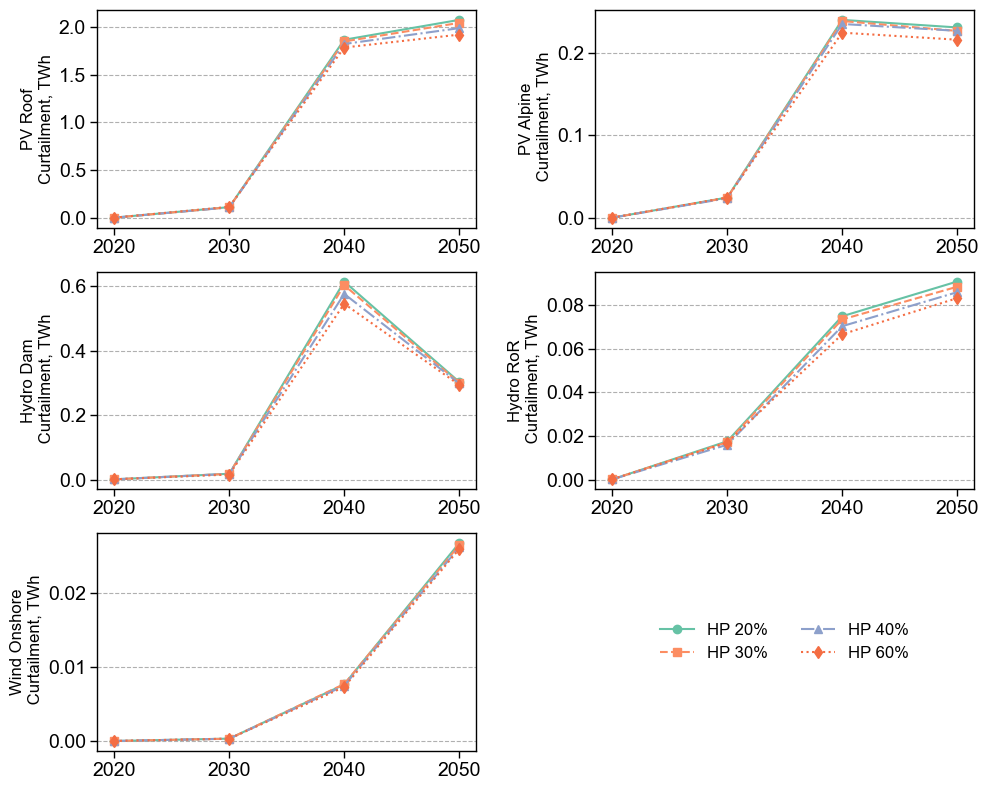

In [12]:
# ================================================================
# This cell analyzes and visualizes the results shown in Fig. 3(b)
# ================================================================


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path

# ---- Configuration ----
# Select the target country for plotting.
country = 'ch'

# Map country codes to full country names.
country_df = {
    'at': 'Austria',
    'ch': 'Switzerland',
    'de': 'Germany',
    'it': 'Italy',
    'fr': 'France'
}

# Define the simulation cases and the labels used in the legend.
cases = {
    'case1a0': 'HP 20%',
    'case1b0': 'HP 30%',
    'case1c0': 'HP 40%',
    'case1d0': 'HP 60%'
}

# Base directory containing the simulation results.
base_path = r'..\Output_data\power systems results'

# Years displayed on the x-axis.
target_years = ['2020', '2030', '2040', '2050']

# Renewable technologies included in the multi-panel figure.
target_tech_list = [
    'PV Roof',
    'PV Alpine',
    'Hydro Dam',
    'Hydro RoR',
    'Wind Onshore'
]

# Define a dedicated y-axis label for each subplot.
ylabels = [
    "PV Roof\nCurtailment, TWh",
    "PV Alpine\n Curtailment, TWh",
    "Hydro Dam\n Curtailment, TWh",
    "Hydro RoR\n Curtailment, TWh",
    "Wind Onshore\n Curtailment, TWh"
]

tick_font_size = 14

# ---- Custom axis styling ----
def apply_axis_style(ax):
    """Apply a consistent visual style to subplot axes."""
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)
    ax.tick_params(axis='x', which='major', pad=3, width=1, length=5, labelsize=tick_font_size)
    ax.tick_params(axis='y', which='major', pad=3, width=1, length=5, labelsize=tick_font_size)

# ---- Load scenario data ----
def load_results_for_tech(target_tech):
    """Load annual curtailment values for one technology across all scenarios."""
    results = {}
    for case, label in cases.items():
        file_path = fr'{base_path}\{case}\national_generation_and_capacity\0-national_curtailment_annual_c_{country}.csv'
        df = pd.read_csv(file_path, index_col=0)

        # Ensure that the requested technology exists in the current result file.
        if target_tech not in df.index:
            raise ValueError(f"{target_tech} not found in {case} data.")

        # Extract annual curtailment values for the requested years.
        values = [df.loc[target_tech, y] if y in df.columns else 0 for y in target_years]
        results[label] = values
    return results

# ---- Plot style definition ----
# Define line styles, markers, and colors for the HP deployment scenarios.
styles = {
    'HP 20%': {'linestyle': '-', 'marker': 'o', 'color': '#66c2a5'},
    'HP 30%': {'linestyle': '--', 'marker': 's', 'color': '#fc8d62'},
    'HP 40%': {'linestyle': '-.', 'marker': '^', 'color': '#8da0cb'},
    'HP 60%': {'linestyle': ':', 'marker': 'd', 'color': '#f46d43'}
}

# ---- Create subplots ----
# Create a 3x2 layout, where the last panel is reserved for the legend.
fig, axes = plt.subplots(3, 2, figsize=(10, 8), facecolor='white')
axes = axes.flatten()

x = np.arange(len(target_years))
legend_ax = axes[-1]  # Reserve the last subplot for the legend only.

# Plot one panel per renewable technology.
for i, target_tech in enumerate(target_tech_list):
    ax = axes[i]
    results = load_results_for_tech(target_tech)

    for label, values in results.items():
        style = styles[label]
        ax.plot(x, values, label=label, **style)

    apply_axis_style(ax)
    ax.set_xticks(x)
    ax.set_xticklabels(target_years)
    ax.set_ylabel(ylabels[i], fontsize=12)  # Set the y-axis label for each subplot individually.
    ax.grid(axis='y', linestyle='--', alpha=1)

# ---- Legend panel ----
legend_ax.axis('off')
lines, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(lines, labels, fontsize=12, loc='center', ncols=2, frameon=False)

plt.tight_layout()
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

# ---- SVG export settings ----
# Keep text editable in the SVG output rather than converting it to paths.
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False  # Avoid LaTeX rendering to prevent text outline conversion.
mpl.rcParams['font.family'] = ['Arial']

# # Define the export path for the figure.
# out_path = Path.cwd() / "main_fig3b.svg"

# # Save the figure as an SVG with a transparent background and tight margins.
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )

# print(f"Saved SVG to: {out_path}")

plt.show()


### Figure 3(c): Trading components in terms of energy

This section compares the trading components in the term of energy across scenarios and years. The plotted results are used to quantify how imports, exports, and related electricity trading indicators evolve under different heat pump penetration levels.

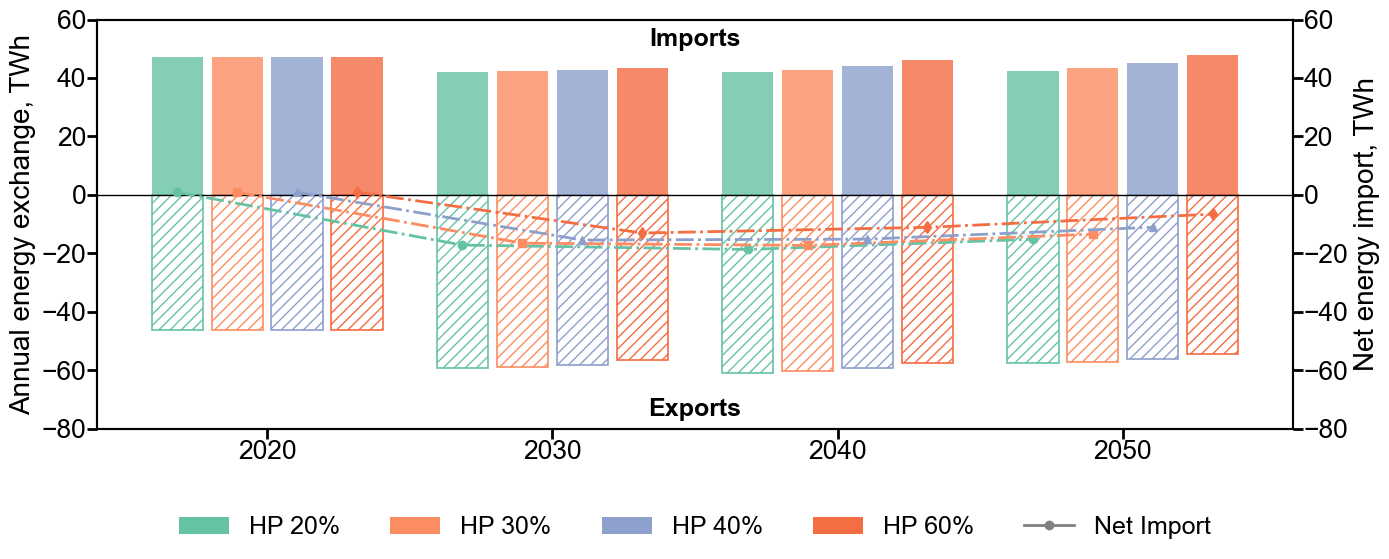

In [13]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 3(c)
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
from pathlib import Path

# ========== Tick style parameters ==========
tick_font_size = 19

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=1, width=2, length=7)
    ax.tick_params(axis='y', which='major', pad=1, width=2, length=7)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ========== Scenario definitions and styles ==========
cases = {
    'case1a0': 'HP 20%',
    'case1b0': 'HP 30%',
    'case1c0': 'HP 40%',
    'case1d0': 'HP 60%'
}

styles = {
    'HP 20%': {'linestyle': '-.', 'marker': 'o', 'color': '#66c2a5'},
    'HP 30%': {'linestyle': '-.', 'marker': 's', 'color': '#fc8d62'},
    'HP 40%': {'linestyle': '-.', 'marker': '^', 'color': '#8da0cb'},
    'HP 60%': {'linestyle': '-.', 'marker': 'd', 'color': '#f46d43'}
}

# ========== General settings ==========
base_path = r'..\Output_data\power systems results'
x_labels = ['2020', '2030', '2040', '2050']
x = np.arange(len(x_labels))
width = 0.18
gap = 0.03  # Additional gap width
n = len(cases)
total_width = n * width + (n - 1) * gap
start = -total_width / 2 + width / 2
offsets = [start + i * (width + gap) for i in range(n)]

# ========== Read data ==========
data_by_case = {}
for case in cases:
    file_path = fr'{base_path}\{case}\national_generation_and_capacity\0-national_generation_annual_twh_c_ch.csv'
    raw_df = pd.read_csv(file_path)
    df = raw_df.set_index('Row').loc[['Imports', 'Exports']]
    data_by_case[case] = df

# ========== Create figure ==========
fig, ax = plt.subplots(figsize=(14, 5.5))
ax2 = ax.twinx()

for i, (case, label) in enumerate(cases.items()):
    df = data_by_case[case]
    imports = df.loc['Imports'].values
    exports = df.loc['Exports'].values
    net = imports + exports

    xpos = x + offsets[i]
    color = styles[label]['color']

    # Primary axis: bar chart
    ax.bar(xpos, imports, width=width, color=color, alpha=0.8)
    ax.bar(xpos, exports, width=width, color='white', edgecolor=color, hatch='///', linewidth=1.2)

    # Secondary axis: line plot
    ax2.plot(xpos, net,
             linestyle=styles[label]['linestyle'],
             marker=styles[label]['marker'],
             color=color, linewidth=2, markersize=6)

# ========== Axis settings ==========
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Annual energy exchange, TWh', fontsize=20)
ax.axhline(y=0, color='black', linewidth=1)
ax.grid(False)

ax2.set_ylabel('Net energy import, TWh', fontsize=20)

# Apply unified styling
apply_axis_style(ax)
apply_axis_style(ax2)

# ========== Set y-axis limits ==========
ax.set_ylim(-80, 60)
ax2.set_ylim(-80, 60)

# ========== Add text annotations ==========
ax.text(0.5, 0.98, 'Imports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='top', color='black')
ax.text(0.5, 0.02, 'Exports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='bottom', color='black')

# ========== Legend (show only scenarios + Net Import) ==========
legend_items = []

# Each scenario is represented by a unified colored patch
for label in cases.values():
    color = styles[label]['color']
    legend_items.append(Patch(facecolor=color, label=label))

# Add the Net Import style entry (gray line)
legend_items.append(plt.Line2D([0], [0], color='gray', linestyle='-', marker='o',
                               linewidth=2, markersize=6, label='Net Import'))

# Display the legend below the plot in one row with five columns
fig.legend(handles=legend_items,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.03),
           ncol=5,
           fontsize=18,
           frameon=False)

# ========== Layout adjustments ==========
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()



### Figure 3(d): Trading components in terms of costs

This section compares the trading components in the term of costs across scenarios and years. The plotted results are used to quantify how imports, exports, and related electricity trading indicators evolve under different heat pump penetration levels.


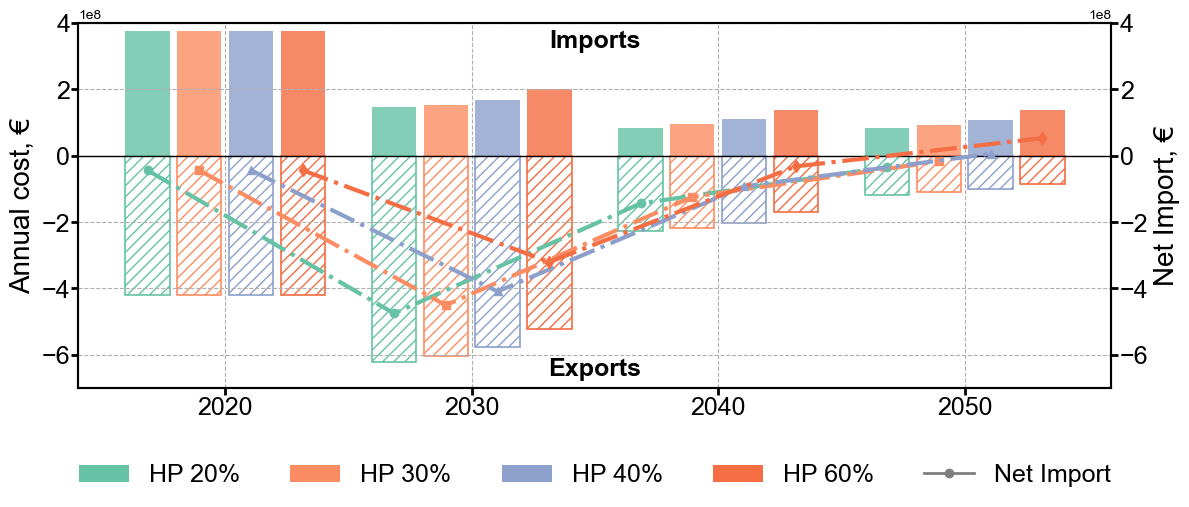

In [14]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 3(d)
# =====================================================================


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path
from matplotlib.patches import Patch

# ========== Unified axis styling ==========
tick_font_size = 18

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=1, width=2, length=5)
    ax.tick_params(axis='y', which='major', pad=1, width=2, length=5)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ========== Scenario definitions and styles ==========
cases = {
    'case1a0': 'HP 20%',
    'case1b0': 'HP 30%',
    'case1c0': 'HP 40%',
    'case1d0': 'HP 60%'
}

styles = {
    'HP 20%': {'linestyle': '-.', 'marker': 'o', 'color': '#66c2a5'},
    'HP 30%': {'linestyle': '-.', 'marker': 's', 'color': '#fc8d62'},
    'HP 40%': {'linestyle': '-.', 'marker': '^', 'color': '#8da0cb'},
    'HP 60%': {'linestyle': '-.', 'marker': 'd', 'color': '#f46d43'}
}

# ========== General settings ==========
base_path = r'..\Output_data\power systems results'
x_labels = ['2020', '2030', '2040', '2050']
x = np.arange(len(x_labels))
width = 0.18

gap = 0.03  # Additional gap width
n = len(cases)
total_width = n * width + (n - 1) * gap
start = -total_width / 2 + width / 2
offsets = [start + i * (width + gap) for i in range(n)]

# ========== Read data ==========
data_by_case = {}
for case in cases:
    file_path = fr'{base_path}\{case}\national_generation_and_capacity\0-systemcosts_trading_5_an.csv'
    raw_df = pd.read_csv(file_path)
    df = raw_df.set_index('Row').loc[['Imports', 'Exports']]
    data_by_case[case] = df

# ========== Create figure ==========
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()  # Plot the net-import line on the secondary axis

for i, (case, label) in enumerate(cases.items()):
    df = data_by_case[case]
    imports = df.loc['Imports'].values
    exports = df.loc['Exports'].values  # Already negative
    net = imports + exports             # Net = Imports - Exports

    xpos = x + offsets[i]
    color = styles[label]['color']

    # ========== Primary axis: bar chart =====
    ax.bar(xpos, imports, width=width, color=color, alpha=0.8)
    ax.bar(xpos, exports, width=width, color='white', edgecolor=color, hatch='///', linewidth=1.2)

    # ========== Secondary axis: line plot =====
    ax2.plot(xpos, net,
             linestyle=styles[label]['linestyle'],
             marker=styles[label]['marker'],
             color=color, linewidth=3, markersize=6)

# ========== Axis settings ==========
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Annual cost, €', fontsize=20)
ax.axhline(y=0, color='black', linewidth=1)
ax.grid(True, linestyle='--', alpha=1)

ax2.set_ylabel('Net Import, €', fontsize=20)
ax2.spines['right'].set_color('gray')

# Apply unified styling
apply_axis_style(ax)
apply_axis_style(ax2)

# Manually set the axis limits so that the zero lines align
ymin, ymax = -7e8, 4e8
ax.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)



# ========== Add text annotations ==========
ax.text(0.5, 0.98, 'Imports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='top', color='black')
ax.text(0.5, 0.02, 'Exports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='bottom', color='black')

# ========== Legend (show only scenarios + Net Import) ==========
legend_items = []

# Each scenario is represented by a unified colored patch
for label in cases.values():
    color = styles[label]['color']
    legend_items.append(Patch(facecolor=color, label=label))

# Add the Net Import style entry (gray line)
legend_items.append(plt.Line2D([0], [0], color='gray', linestyle='-', marker='o',
                               linewidth=2, markersize=6, label='Net Import'))

# Display the legend below the plot in one row with five columns
fig.legend(handles=legend_items,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.03),
           ncol=5,
           fontsize=18,
           frameon=False)

# ========== Layout adjustments ==========
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()


### Figure 3(e): Multi-country annual electricity price comparison across HP deployment scenarios

This section reads the annual electricity price results for Switzerland and neighbouring countries and visualizes the country-level trajectories across multiple HP deployment scenarios.

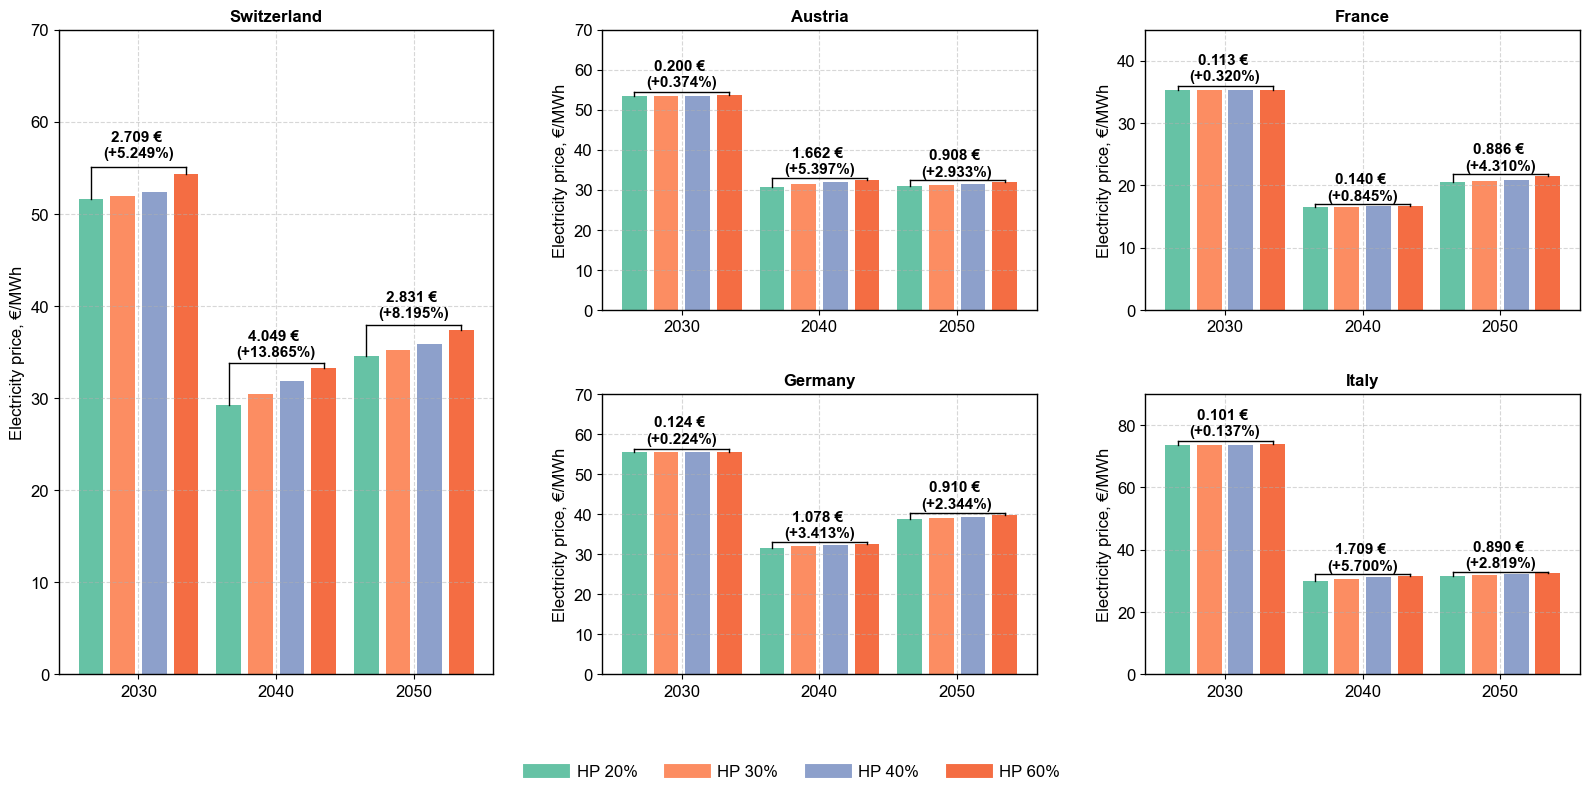

In [15]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 3(e)
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib
import matplotlib as mpl
from pathlib import Path

# === Visual styling ===
matplotlib.rcParams['axes.linewidth'] = 2.5

# === Define scenario parameters ===
cases = ['case1a0', 'case1b0', 'case1c0', 'case1d0']
case_labels = {
    'case1a0': 'HP 20%',
    'case1b0': 'HP 30%',
    'case1c0': 'HP 40%',
    'case1d0': 'HP 60%'
}
styles = {
    'HP 20%': {'color': '#66c2a5'},
    'HP 30%': {'color': '#fc8d62'},
    'HP 40%': {'color': '#8da0cb'},
    'HP 60%': {'color': '#f46d43'}
}
years = ['2030', '2040', '2050']

# Define the plotting order (Switzerland occupies the full left column)
country_order = ['Switzerland', 'Austria', 'France', 'Germany', 'Italy']

# === Font sizes ===
tick_font_size = 12
label_font_size = 12
diff_font_size = 11
legend_font_size = 12

# === Manual y-axis limits ===
ylim_dict = {
    'Austria': (0, 70),
    'France': (0, 45),
    'Germany': (0, 70),
    'Italy': (0, 90),
    'Switzerland': (0, 70)
}

# === Read annual electricity price data ===
data_dict = {}
for case in cases:
    path = fr'..\Output_data\power systems results\{case}\national_generation_and_capacity\0-national_elecprice_annual_c.csv'
    df = pd.read_csv(path)
    df.set_index('Row', inplace=True)
    df = df[~df.index.str.lower().str.contains("date")]
    data_dict[case] = df

# === Configure subplot layout (Switzerland spans the full left column) ===
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)  # 2-row by 3-column grid

# Allocate the entire left column to Switzerland
ax_sw = fig.add_subplot(gs[:, 0])

# Place the four neighbouring countries on the right-hand side
ax_right = [
    fig.add_subplot(gs[0, 1]),  # Austria
    fig.add_subplot(gs[0, 2]),  # France
    fig.add_subplot(gs[1, 1]),  # Germany
    fig.add_subplot(gs[1, 2])   # Italy
]

axes = [ax_sw] + ax_right

# === Define grouped-bar layout ===
bar_width = 0.18
inter_case_gap = 0.05
x = np.arange(len(years))

# === Plot results for each country ===
for idx, country in enumerate(country_order):
    ax = axes[idx]
    offset = -((len(cases)-1)/2)*(bar_width + inter_case_gap)

    y_a = data_dict['case1a0'].loc[country, years].astype(float).values
    y_d = data_dict['case1d0'].loc[country, years].astype(float).values

    for k, case in enumerate(cases):
        label = case_labels[case]
        color = styles[label]['color']
        y = data_dict[case].loc[country, years].astype(float).values
        pos = x + offset + k * (bar_width + inter_case_gap)
        ax.bar(pos, y, width=bar_width, color=color, label=label)

    # === Annotate HP 60% - HP 13% difference ===
    diff = y_d - y_a
    perc = (diff / y_a) * 100

    for j in range(len(years)):
        y1 = y_a[j]
        y2 = y_d[j]
        pos_13 = x[j] + offset + 0 * (bar_width + inter_case_gap)
        pos_60 = x[j] + offset + 3 * (bar_width + inter_case_gap)

        line_y = max(y1, y2) * 1.015
        tick_height = max(y1, y2) * 0.012

        ax.plot([pos_13, pos_60], [line_y, line_y], color='black', linewidth=1.0)
        ax.plot([pos_13, pos_13], [y1, line_y], color='black', linewidth=1.0)
        ax.plot([pos_60, pos_60], [y2, line_y], color='black', linewidth=1.0)

        ax.text((pos_13 + pos_60) / 2, line_y + tick_height,
                f"{diff[j]:.3f} € \n({perc[j]:+.3f}%)",
                ha='center', va='bottom', fontsize=diff_font_size, fontweight='bold', color='black')

    # === Titles, axes, formatting ===
    ax.set_title(country, fontsize=label_font_size, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=tick_font_size)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.set_ylabel('Electricity price, €/MWh', fontsize=label_font_size)
    ax.grid(True, linestyle='--', alpha=0.5)

    if country in ylim_dict:
        ax.set_ylim(*ylim_dict[country])

    for spine in ax.spines.values():
        spine.set_linewidth(1)

# === Legend BELOW all subplots ===
handles = [Line2D([0], [0], color=styles[case_labels[c]]['color'], lw=10, label=case_labels[c]) for c in cases]
fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.00),
           fontsize=legend_font_size,
           frameon=False,
           ncol=4)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15,wspace=0.25, hspace=0.3)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ======================= SVG export for editable text in Adobe Illustrator =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid text-to-path conversion
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify if needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save the figure as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()
